# PCA и повороты (молекулы) — как сжатие GIN влияет на бустинг

Молекулярный аналог `protein_embeddings/pca_rotation_screening.ipynb`, но
**наоборот**: белковая сторона зафиксирована, варьируем молекулярную.

- **Белок:** ESM mean (1280-d) сжимается PCA до **k_prot = 19** компонент и
  держится constant во всех прогонах этого ноутбука. `19` — одна из точек
  log-сетки в протеиновом ноутбуке; фиксируя её здесь, мы изолируем эффект
  именно молекулярного PCA, не смешивая его с одновременным варьированием
  белковой стороны.
- **Молекула:** GIN (300-d) проецируется на первые `k_mol` компонент; `k_mol`
  бежит по log-сетке из 10 значений. GIN размерность всего 300 (меньше, чем
  число молекул-1=487) — значит потолок сжатия **300, а не 487**: полный ранг
  упирается в размерность эмбеддинга, а не в размер выборки.

Оба PCA-преобразования обучаются **только на train-стороне** сплита (train-
рецепторы для белка, train-молекулы для лиганда) — без утечки в тест.

**Гипотеза:** та же rotation non-invariance деревьев, что мы видели на белках,
должна проявиться и здесь: почти-безпотерьный PCA (k_mol≈300) вероятно всё
равно уступит настоящему сырому GIN.

In [31]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from orbind import dataset as D
from orbind.baselines import make_xy, train_boost

DATA  = ROOT / 'data'
FIG   = ROOT / 'notebooks' / 'molecule_embeddings' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / 'notebooks' / 'cache'; CACHE.mkdir(parents=True, exist_ok=True)
print('repo root:', ROOT)

repo root: <repo>


In [32]:
# --- данные -------------------------------------------------------------
PAIRS = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
_esm_full = D.load_npz_dict(DATA / 'embeddings' / 'proteins' / 'esm2_650m_mean.npz')
ESM   = {k: v for k, v in _esm_full.items() if k in set(PAIRS['receptor'])}
GIN   = D.load_npz_dict(DATA / 'embeddings' / 'molecules' / 'gin_supervised_contextpred_all_m2or.npz')
print(f'pairs={len(PAIRS)} | proteins={len(ESM)} | molecules={len(GIN)}')

N_MOL     = len(GIN)                       # 488 curated-молекул
GIN_DIM   = next(iter(GIN.values())).shape[0]           # 300
MAX_RANK_MOL = min(GIN_DIM, N_MOL - 1)      # потолок сжатия ограничен размерностью GIN, не числом молекул
K_PROT_FIXED = 19                           # фиксированное сжатие белка (точка из protein-ноутбука)
print(f'GIN dim={GIN_DIM}  молекул={N_MOL}  максимальный ранг PCA(GIN)={MAX_RANK_MOL}')
print(f'белок зафиксирован: ESM -> PCA -> k_prot={K_PROT_FIXED}')

pairs=21384 | proteins=409 | molecules=488
GIN dim=300  молекул=488  максимальный ранг PCA(GIN)=300
белок зафиксирован: ESM -> PCA -> k_prot=19


## Сетка числа молекулярных компонент

10 значений `k_mol`, логарифмически распределённых от малого до почти-предела
размерности GIN (300) — гуще у малых значений.

In [33]:
# --- сетка k_mol (log-spaced, гуще у малых значений) --------------------
N_POINTS = 10
K_MIN, K_MAX = 4, MAX_RANK_MOL - 8
K_GRID_MOL = sorted(set(np.round(np.geomspace(K_MIN, K_MAX, N_POINTS)).astype(int).tolist()))
print(f'k_mol grid ({len(K_GRID_MOL)} точек): {K_GRID_MOL}')

k_mol grid (10 точек): [4, 6, 10, 17, 27, 43, 70, 113, 181, 292]


## PCA-трансформ (переиспользуем ту же схему, что и для белков)

Обучается на train-идентичностях (рецепторах или молекулах — в зависимости от
того, к какому эмбеддингу применяется), проецирует train+test одним и тем же
базисом.

In [34]:
def pca_transform(emb: dict, train_keys: list, k: int) -> dict:
    """Fit PCA on train-side keys only; project ALL keys into the resulting
    k-dim basis. No test-set leakage into the PCA fit."""
    keys_all  = list(emb.keys())
    X_all     = np.stack([emb[key] for key in keys_all]).astype(np.float64)
    X_train   = np.stack([emb[key] for key in train_keys]).astype(np.float64)

    mu = X_train.mean(0, keepdims=True)
    Xc_train = X_train - mu
    U, S, Vt = np.linalg.svd(Xc_train, full_matrices=False)
    kk = min(k, Vt.shape[0])
    comps = Vt[:kk]

    proj = (X_all - mu) @ comps.T
    if kk < k:
        proj = np.pad(proj, ((0, 0), (0, k - kk)))
    return {key: v.astype(np.float32) for key, v in zip(keys_all, proj)}


def run_pca_boost_mol(pairs, prot, mol, split, k_prot, k_mol, seed=42, test_size=0.2):
    """split -> PCA(k_prot) on train receptors + PCA(k_mol) on train molecules
    -> assemble X -> boost -> metrics."""
    mask = pairs['receptor'].isin(prot) & pairs['inchikey'].isin(mol)
    p = pairs[mask].reset_index(drop=True)
    y = p['label'].to_numpy(dtype=np.float32)

    tr, te = D.split(p, y, kind=split, test_size=test_size, seed=seed)
    train_recs = p['receptor'][tr].unique().tolist()
    train_mols = p['inchikey'][tr].unique().tolist()

    prot_k = pca_transform(prot, train_recs, k_prot) if k_prot is not None else prot
    mol_k  = pca_transform(mol,  train_mols, k_mol)  if k_mol  is not None else mol

    X, y2, _ = make_xy(p, prot_k, mol_k, seed=seed)
    pred = train_boost(X[tr], y2[tr], X[te], seed=seed)
    info = {'train': int(tr.sum()), 'test': int(te.sum()), 'test_pos': int(y2[te].sum())}
    return D.metrics(y2[te], pred), info

## Дисковый кэш результатов

Свой файл (`pca_rotation_screening_molecule.json`) — изолирован от белкового
ноутбука и остальных бейзлайнов.

In [35]:
# --- дисковый кэш --------------------------------------------------------
import json
CFILE = CACHE / 'pca_rotation_screening_molecule.json'
_cache = json.loads(CFILE.read_text()) if CFILE.exists() else {}

def _save(): CFILE.write_text(json.dumps(_cache, indent=2))

SPLITS = ['stratified', 'group_molecule', 'group_receptor']
SEED   = 42

def cached_mol_run(k_mol, split, k_prot=K_PROT_FIXED, seed=SEED, force=False):
    key = f'prot{k_prot}_mol{k_mol}|boost|{split}|seed{seed}'
    if key in _cache and not force:
        return _cache[key]
    m, info = run_pca_boost_mol(PAIRS, ESM, GIN, split, k_prot, k_mol, seed=seed)
    rec = {'k_mol': k_mol, 'k_prot': k_prot, 'split': split, 'seed': seed,
           **{kk: round(float(v), 4) for kk, v in m.items()}, **info}
    _cache[key] = rec; _save()
    return rec

def cached_mol_raw_run(split, k_prot=K_PROT_FIXED, seed=SEED, force=False):
    """Честный контроль: белок PCA-k_prot (как везде в этом ноутбуке), молекула — БЕЗ PCA."""
    key = f'prot{k_prot}_molRAW|boost|{split}|seed{seed}'
    if key in _cache and not force:
        return _cache[key]
    m, info = run_pca_boost_mol(PAIRS, ESM, GIN, split, k_prot, None, seed=seed)
    rec = {'k_mol': 'raw', 'k_prot': k_prot, 'split': split, 'seed': seed,
           **{kk: round(float(v), 4) for kk, v in m.items()}, **info}
    _cache[key] = rec; _save()
    return rec

## Прогон грида (кэшируется, авто-пропуск готового)

Каждый `k_mol` x 3 сплита x **3 разных сида** (`SEEDS`). Сид одновременно
определяет и разбиение train/test (`D.split(..., seed=seed)`), и инициализацию
XGBoost — три независимых повторения дают **доверительный интервал** (среднее
± std) для каждой точки на итоговом графике, вместо одной шумной точки.

Плюс контрольные точки (тоже по 3 сида):
- `k_mol = raw` — сырой GIN без PCA (истинная опорная точка);
- `k_mol = 300` — PCA почти без потерь по дисперсии молекул (полный ранг GIN).

In [36]:
# --- прогон грида (10 точек x 3 сплита x 3 сида) ----------------------------
SEEDS = [42, 7, 123]

rows = []
for k_mol in K_GRID_MOL:
    for split in SPLITS:
        for seed in SEEDS:
            rows.append(cached_mol_run(k_mol, split, seed=seed))
    print(f"  k_mol={k_mol:>4}  готово ({len(SPLITS)}x{len(SEEDS)} прогонов на сплиты x сиды)")

for split in SPLITS:                                         # k_mol = 300 (почти полный ранг)
    for seed in SEEDS:
        rows.append(cached_mol_run(GIN_DIM, split, seed=seed))
print(f"  k_mol={GIN_DIM}  (почти полный ранг) готово")

for split in SPLITS:                                         # k_mol = raw (истинный контроль)
    for seed in SEEDS:
        rows.append(cached_mol_raw_run(split, seed=seed))
print(f"  k_mol=raw (сырой GIN) готово")

RES = pd.DataFrame(rows).drop_duplicates(subset=['k_mol', 'split', 'seed'], keep='last')
print(f"\nвсего конфигураций: {len(RES)}  (белок зафиксирован: PCA-{K_PROT_FIXED}, "
      f"{len(SEEDS)} сида на точку)")

  k_mol=   4  готово (3x3 прогонов на сплиты x сиды)
  k_mol=   6  готово (3x3 прогонов на сплиты x сиды)
  k_mol=  10  готово (3x3 прогонов на сплиты x сиды)
  k_mol=  17  готово (3x3 прогонов на сплиты x сиды)
  k_mol=  27  готово (3x3 прогонов на сплиты x сиды)
  k_mol=  43  готово (3x3 прогонов на сплиты x сиды)
  k_mol=  70  готово (3x3 прогонов на сплиты x сиды)
  k_mol= 113  готово (3x3 прогонов на сплиты x сиды)
  k_mol= 181  готово (3x3 прогонов на сплиты x сиды)
  k_mol= 292  готово (3x3 прогонов на сплиты x сиды)
  k_mol=300  (почти полный ранг) готово
  k_mol=raw (сырой GIN) готово

всего конфигураций: 108  (белок зафиксирован: PCA-19, 3 сида на точку)


## График: качество бустинга vs число молекулярных PCA-компонент

Ось `k_mol` — логарифмическая. Точки — **среднее по 3 сидам**, усы —
**± std**. Звёздочка `*` справа — честный сырой GIN (`raw`); пунктир отмечает
`k_mol=300` (почти полный ранг GIN).

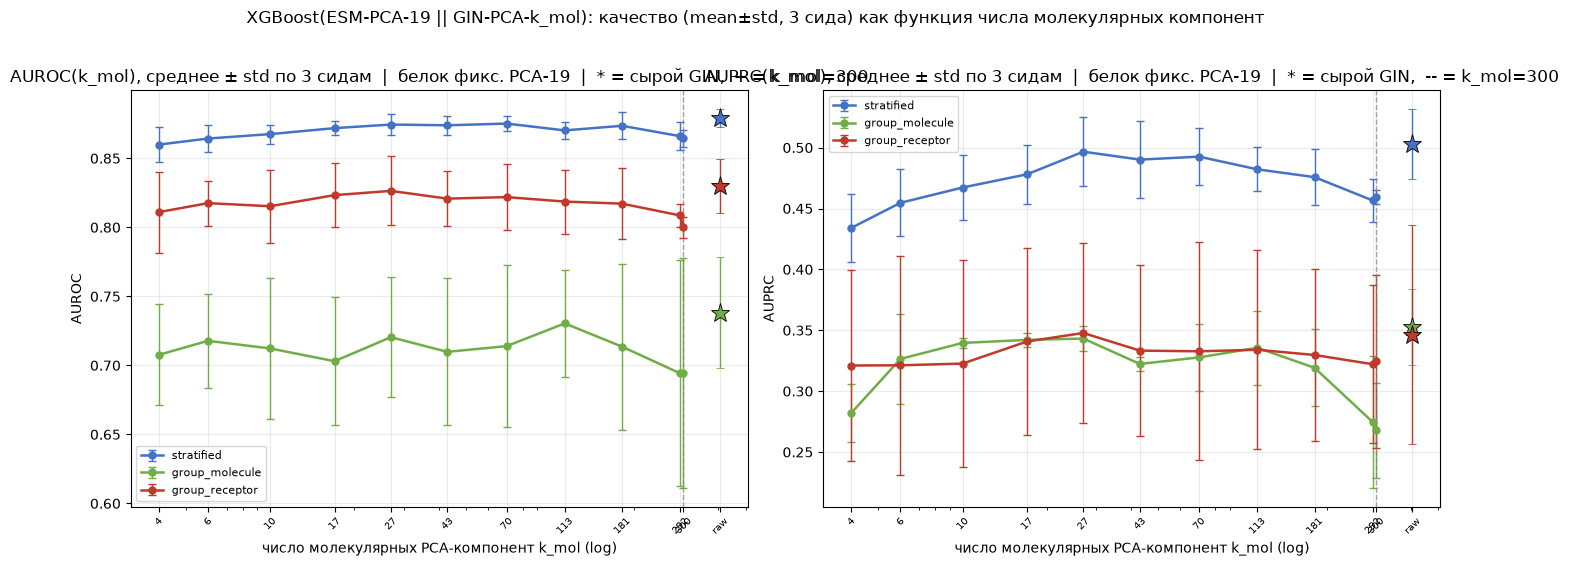

saved -> pca_k_mol_curve.png


In [37]:
# --- график AUROC/AUPRC(k_mol) по трём сплитам, среднее ± std по 3 сидам ---
RAW_X = int(MAX_RANK_MOL * 1.35)

def agg_mean_std(df, metric):
    g = df.groupby(['k_mol', 'split'])[metric]
    return g.mean().rename('mean').to_frame().join(g.std().rename('std'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = {'stratified': '#4472C4', 'group_molecule': '#70AD47', 'group_receptor': '#C0392B'}

for metric, ax in zip(['AUROC', 'AUPRC'], axes):
    agg = agg_mean_std(RES, metric).reset_index()
    for split in SPLITS:
        sub = agg[agg['split'] == split]
        num = sub[sub['k_mol'] != 'raw'].assign(k_mol=lambda d: d['k_mol'].astype(int)).sort_values('k_mol')
        ax.errorbar(num['k_mol'], num['mean'], yerr=num['std'], marker='o', color=colors[split],
                    label=split, lw=1.8, ms=5, capsize=3, elinewidth=1)
        raw = sub[sub['k_mol'] == 'raw']
        if not raw.empty:
            ax.errorbar([RAW_X], raw['mean'], yerr=raw['std'], color=colors[split], marker='*',
                        ms=14, mec='k', mew=0.6, capsize=3, elinewidth=1, ls='none', zorder=5)

    ax.axvline(GIN_DIM, color='gray', ls='--', lw=1, alpha=0.7)
    ax.set_xscale('log')
    ax.set_xticks(list(K_GRID_MOL) + [GIN_DIM, RAW_X])
    ax.set_xticklabels([str(k) for k in K_GRID_MOL] + [f'{GIN_DIM}', 'raw'], rotation=45, fontsize=7)
    ax.set_xlabel('число молекулярных PCA-компонент k_mol (log)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}(k_mol), среднее ± std по {len(SEEDS)} сидам  |  белок фикс. PCA-{K_PROT_FIXED}  |  '
                 f'* = сырой GIN,  -- = k_mol={GIN_DIM}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle(f'XGBoost(ESM-PCA-19 || GIN-PCA-k_mol): качество (mean±std, {len(SEEDS)} сида) '
             f'как функция числа молекулярных компонент', y=1.02)
fig.tight_layout()
fname = FIG / 'pca_k_mol_curve.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname.name}')

## Таблица результатов

In [38]:
# --- сводная таблица (среднее ± std по 3 сидам) -----------------------------
order = K_GRID_MOL + [GIN_DIM, 'raw']

def fmt_table(metric):
    agg = RES.groupby(['k_mol', 'split'])[metric].agg(['mean', 'std'])
    def fmt(row):
        return f"{row['mean']:.3f} ± {row['std']:.3f}" if pd.notna(row['std']) else f"{row['mean']:.3f}"
    return agg.apply(fmt, axis=1).unstack('split').reindex(order)[SPLITS]

print(f'=== AUROC (mean ± std по {len(SEEDS)} сидам) ===')
display(fmt_table('AUROC'))
print(f'\n=== AUPRC (mean ± std по {len(SEEDS)} сидам) ===')
display(fmt_table('AUPRC'))

=== AUROC (mean ± std по 3 сидам) ===


split,stratified,group_molecule,group_receptor
k_mol,,,
4,0.860 ± 0.013,0.708 ± 0.037,0.811 ± 0.029
6,0.864 ± 0.010,0.718 ± 0.034,0.818 ± 0.016
10,0.868 ± 0.007,0.712 ± 0.051,0.815 ± 0.026
17,0.872 ± 0.005,0.703 ± 0.046,0.823 ± 0.023
27,0.874 ± 0.008,0.720 ± 0.044,0.826 ± 0.025
43,0.874 ± 0.007,0.710 ± 0.053,0.821 ± 0.020
70,0.875 ± 0.006,0.714 ± 0.058,0.822 ± 0.024
113,0.870 ± 0.006,0.730 ± 0.039,0.819 ± 0.023
181,0.874 ± 0.010,0.714 ± 0.060,0.817 ± 0.026



=== AUPRC (mean ± std по 3 сидам) ===


split,stratified,group_molecule,group_receptor
k_mol,,,
4,0.434 ± 0.028,0.282 ± 0.024,0.321 ± 0.079
6,0.455 ± 0.028,0.327 ± 0.037,0.321 ± 0.090
10,0.467 ± 0.027,0.340 ± 0.004,0.323 ± 0.085
17,0.478 ± 0.024,0.342 ± 0.006,0.341 ± 0.077
27,0.497 ± 0.028,0.343 ± 0.010,0.348 ± 0.074
43,0.490 ± 0.032,0.322 ± 0.006,0.333 ± 0.070
70,0.493 ± 0.023,0.328 ± 0.028,0.333 ± 0.090
113,0.482 ± 0.018,0.336 ± 0.030,0.334 ± 0.082
181,0.476 ± 0.023,0.319 ± 0.032,0.330 ± 0.071


---
## Контролируемый эксперимент: конкатенация случайно повёрнутых копий PCA-27

Прямая проверка гипотезы «поворот не добавляет информации, но даёт дереву
больше углов среза». Берём `PCA-27` (train-fit, как везде выше) и строим три
варианта признаков одинаковой структуры:

- **без поворота** — просто `PCA-27` (27-d), базовая точка;
- **+1 поворот** — `Z ‖ rot₁(Z)`: та же матрица `Z`, но с добавленной копией,
  повёрнутой случайной **ортогональной** матрицей `Q₁` (54-d). Никакой новой
  информации: `rot₁(Z)` линейно выражается через `Z`;
- **+2 поворота** — `Z ‖ rot₁(Z) ‖ rot₂(Z)`: то же самое, плюс ещё одна
  независимая случайная ротация `Q₂` (81-d).

**Контроль на дублирование мы уже проверили раньше** (без поворота, просто
`Z ‖ Z`): для дерева повторяющийся столбец не даёт новых сплитов и эффекта не
даёт — вывод сделан, повторно не гоняем, чтобы не тратить компьют.

**Как получить "действительно достаточно случайный" поворот.** Простой
`np.linalg.qr` случайной гауссовской матрицы даёт `Q`, но распределение знаков
столбцов **не** равномерно (не Хаар-случайно). Используем стандартную
поправку (Mezzadri, 2006): `Q *= sign(diag(R))` — после неё `Q` равномерно
распределена по ортогональной группе `O(k)`.

**Доверительный интервал по 3 сидам.** Сид одновременно определяет train/test
сплит, инициализацию XGBoost **и** сами матрицы `Q₁, Q₂` (`rot_seed=seed`) —
так что усы на графике отражают неопределённость не только от сплита/бустинга,
но и от того, *какой именно* случайный поворот выпал.

In [39]:
# --- Хаар-случайная ортогональная матрица (Mezzadri, 2006) -----------------
def random_orthogonal(dim: int, rng: np.random.Generator) -> np.ndarray:
    """Uniformly (Haar) distributed random orthogonal matrix via QR + sign fix.
    Naive QR of a Gaussian matrix is NOT Haar-uniform (columns are biased in
    sign); multiplying by sign(diag(R)) corrects this — the standard trick."""
    A = rng.standard_normal((dim, dim))
    Q, R = np.linalg.qr(A)
    Q = Q * np.sign(np.diag(R))
    return Q


def augment_concat(Z: dict, n_copies: int, rotate: bool, seed: int) -> dict:
    """Concatenate n_copies of the SAME k-dim embedding Z.
    rotate=True  -> each extra copy is Z @ Q_i for an independent Haar-random
                    orthogonal Q_i (no new information, new axes/viewing angles).
    rotate=False -> each extra copy is an exact duplicate of Z (degenerate for
                    trees: identical columns give no new split options)."""
    rng = np.random.default_rng(seed)
    keys = list(Z.keys())
    dim = len(Z[keys[0]])
    mats = [np.eye(dim, dtype=np.float32)]
    for _ in range(n_copies - 1):
        mats.append(random_orthogonal(dim, rng).astype(np.float32) if rotate
                    else np.eye(dim, dtype=np.float32))
    out = {}
    for k in keys:
        z = Z[k]
        out[k] = np.concatenate([z @ M for M in mats]).astype(np.float32)
    return out

In [40]:
K_ROT_BASE = 27   # берём PCA-27 (точка из основной сетки k_mol)

def run_rotaug_boost(pairs, prot, mol, split, k_prot, k_base, n_copies, rotate,
                     seed=42, rot_seed=123, test_size=0.2):
    """split -> PCA(k_prot) на белке + PCA(k_base) на молекуле (train-fit) ->
    конкатенация n_copies повёрнутых/дублированных копий молекулярного блока
    -> boost -> metrics."""
    mask = pairs['receptor'].isin(prot) & pairs['inchikey'].isin(mol)
    p = pairs[mask].reset_index(drop=True)
    y = p['label'].to_numpy(dtype=np.float32)

    tr, te = D.split(p, y, kind=split, test_size=test_size, seed=seed)
    train_recs = p['receptor'][tr].unique().tolist()
    train_mols = p['inchikey'][tr].unique().tolist()

    prot_k = pca_transform(prot, train_recs, k_prot)
    mol_base = pca_transform(mol, train_mols, k_base)
    mol_aug = augment_concat(mol_base, n_copies, rotate, seed=rot_seed)

    X, y2, _ = make_xy(p, prot_k, mol_aug, seed=seed)
    pred = train_boost(X[tr], y2[tr], X[te], seed=seed)
    info = {'train': int(tr.sum()), 'test': int(te.sum()), 'test_pos': int(y2[te].sum())}
    return D.metrics(y2[te], pred), info


CFILE_ROT = CACHE / 'pca_rotation_augmentation.json'
_cache_rot = json.loads(CFILE_ROT.read_text()) if CFILE_ROT.exists() else {}

def _save_rot(): CFILE_ROT.write_text(json.dumps(_cache_rot, indent=2))

def cached_rotaug_run(n_copies, rotate, split, k_prot=K_PROT_FIXED, k_base=K_ROT_BASE,
                      seed=SEED, rot_seed=123, force=False):
    tag = ('rot' if rotate else 'dup') + str(n_copies)
    key = f'prot{k_prot}_mol{k_base}_{tag}|boost|{split}|seed{seed}'
    if key in _cache_rot and not force:
        return _cache_rot[key]
    m, info = run_rotaug_boost(PAIRS, ESM, GIN, split, k_prot, k_base, n_copies, rotate,
                               seed=seed, rot_seed=rot_seed)
    rec = {'variant': tag, 'n_copies': n_copies, 'rotate': rotate, 'dim': k_base * n_copies,
           'split': split, 'seed': seed,
           **{kk: round(float(v), 4) for kk, v in m.items()}, **info}
    _cache_rot[key] = rec; _save_rot()
    return rec

In [41]:
# --- прогон: только rotate, n_copies in {1,2,3} x 3 сплита x 3 сида --------
# (дублирование уже проверено раньше — эффекта не даёт, повторно не гоняем)
rot_rows = []
for n_copies in [1, 2, 3]:
    for split in SPLITS:
        for seed in SEEDS:
            r = cached_rotaug_run(n_copies, True, split, seed=seed, rot_seed=seed)
            rot_rows.append(r)
    print(f"  n_copies={n_copies}  (dim={K_ROT_BASE * n_copies:>3})  готово "
          f"({len(SPLITS)}x{len(SEEDS)} прогонов на сплиты x сиды)")

ROT_RES = pd.DataFrame(rot_rows).drop_duplicates(subset=['variant', 'split', 'seed'], keep='last')
print(f"\nвсего конфигураций: {len(ROT_RES)}  (белок фикс. PCA-{K_PROT_FIXED}, "
      f"молекула база PCA-{K_ROT_BASE}, {len(SEEDS)} сида на точку)")

  n_copies=1  (dim= 27)  готово (3x3 прогонов на сплиты x сиды)
  n_copies=2  (dim= 54)  готово (3x3 прогонов на сплиты x сиды)
  n_copies=3  (dim= 81)  готово (3x3 прогонов на сплиты x сиды)

всего конфигураций: 27  (белок фикс. PCA-19, молекула база PCA-27, 3 сида на точку)


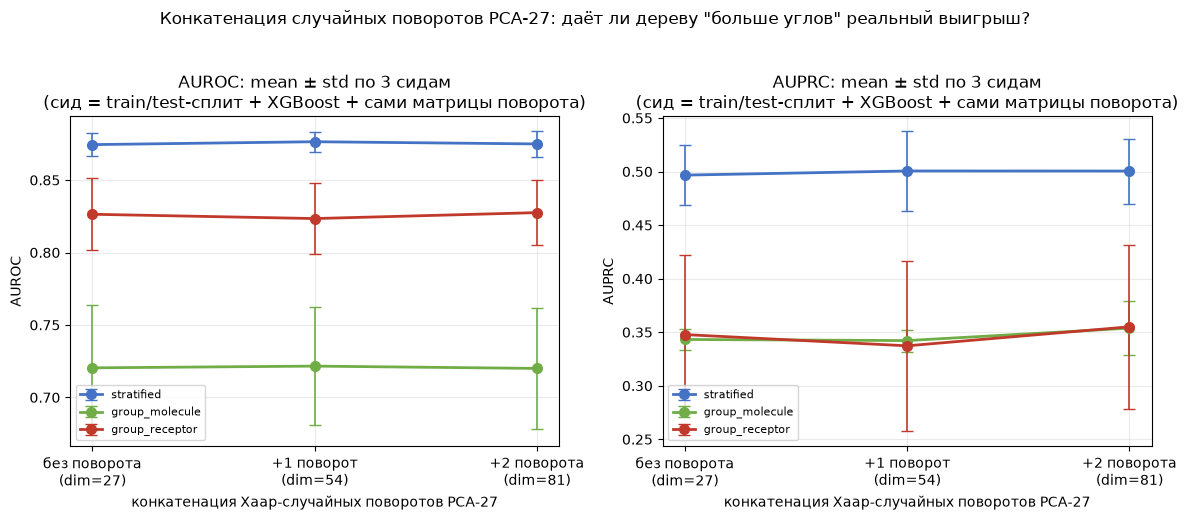

saved -> rotation_augmentation.png


In [42]:
# --- график: качество vs число повёрнутых копий, mean ± std по 3 сидам -----
def agg_rot(df, metric):
    g = df.groupby(['n_copies', 'split'])[metric]
    return g.mean().rename('mean').to_frame().join(g.std().rename('std')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'stratified': '#4472C4', 'group_molecule': '#70AD47', 'group_receptor': '#C0392B'}

for metric, ax in zip(['AUROC', 'AUPRC'], axes):
    agg = agg_rot(ROT_RES, metric)
    for split in SPLITS:
        sub = agg[agg['split'] == split].sort_values('n_copies')
        ax.errorbar(sub['n_copies'], sub['mean'], yerr=sub['std'], marker='o',
                    color=colors[split], label=split, lw=2, ms=7, capsize=4, elinewidth=1.2)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([f'без поворота\n(dim={K_ROT_BASE})',
                        f'+1 поворот\n(dim={K_ROT_BASE * 2})',
                        f'+2 поворота\n(dim={K_ROT_BASE * 3})'])
    ax.set_xlabel('конкатенация Хаар-случайных поворотов PCA-27')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}: mean ± std по {len(SEEDS)} сидам\n'
                 f'(сид = train/test-сплит + XGBoost + сами матрицы поворота)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle(f'Конкатенация случайных поворотов PCA-{K_ROT_BASE}: даёт ли дереву '
             f'"больше углов" реальный выигрыш?', y=1.03)
fig.tight_layout()
fname = FIG / 'rotation_augmentation.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname.name}')

---
## Дисперсия сырых координат: GIN, PCA-27, и повёрнутые конкатенации (54-d, 81-d)

Расширяем сравнение "сырые координаты GIN vs спектр PCA" двумя дополнительными
панелями — дисперсией по координатам самих **аугментированных** признаков из
эксперимента с поворотами (PCA-27 + повороты, 54-d и 81-d).

Использована **дисперсия на всём датасете** (488 молекул, PCA и повороты
подогнаны на всех молекулах, seed фиксирован для воспроизводимости картинки)
— это чисто описательная диагностика, никак не участвует в обучении моделей
(бустинги выше используют train-only PCA и свои сиды).

- **A.** Дисперсия 300 сырых координат GIN, отсортированная по убыванию.
- **B.** Спектр PCA (собственные значения ковариации, тоже 300).
- **C.** Дисперсия координат `PCA-27 ‖ rot₁(PCA-27)` (54-d), отсортировано.
- **D.** Дисперсия координат `PCA-27 ‖ rot₁ ‖ rot₂` (81-d), отсортировано.

Повороты ортогональны, поэтому суммарная дисперсия каждого добавленного блока
(27 координат) равна суммарной дисперсии исходного PCA-27 — но **распределена
по этим 27 осям иначе**: случайный поворот "перемешивает" резко убывающий
спектр PCA в нечто более равномерное внутри блока. Отсюда суммы C = 2×B(27),
D = 3×B(27), а форма — другая.

A (GIN raw, 300d):     сумма дисперсий = 5.375
B (PCA spectrum, 300): сумма дисперсий = 5.375  (= A)
C (PCA27+1rot, 54d):   сумма дисперсий = 8.516  (= 2 x сумма var PCA-27)
D (PCA27+2rot, 81d):   сумма дисперсий = 12.773  (= 3 x сумма var PCA-27)


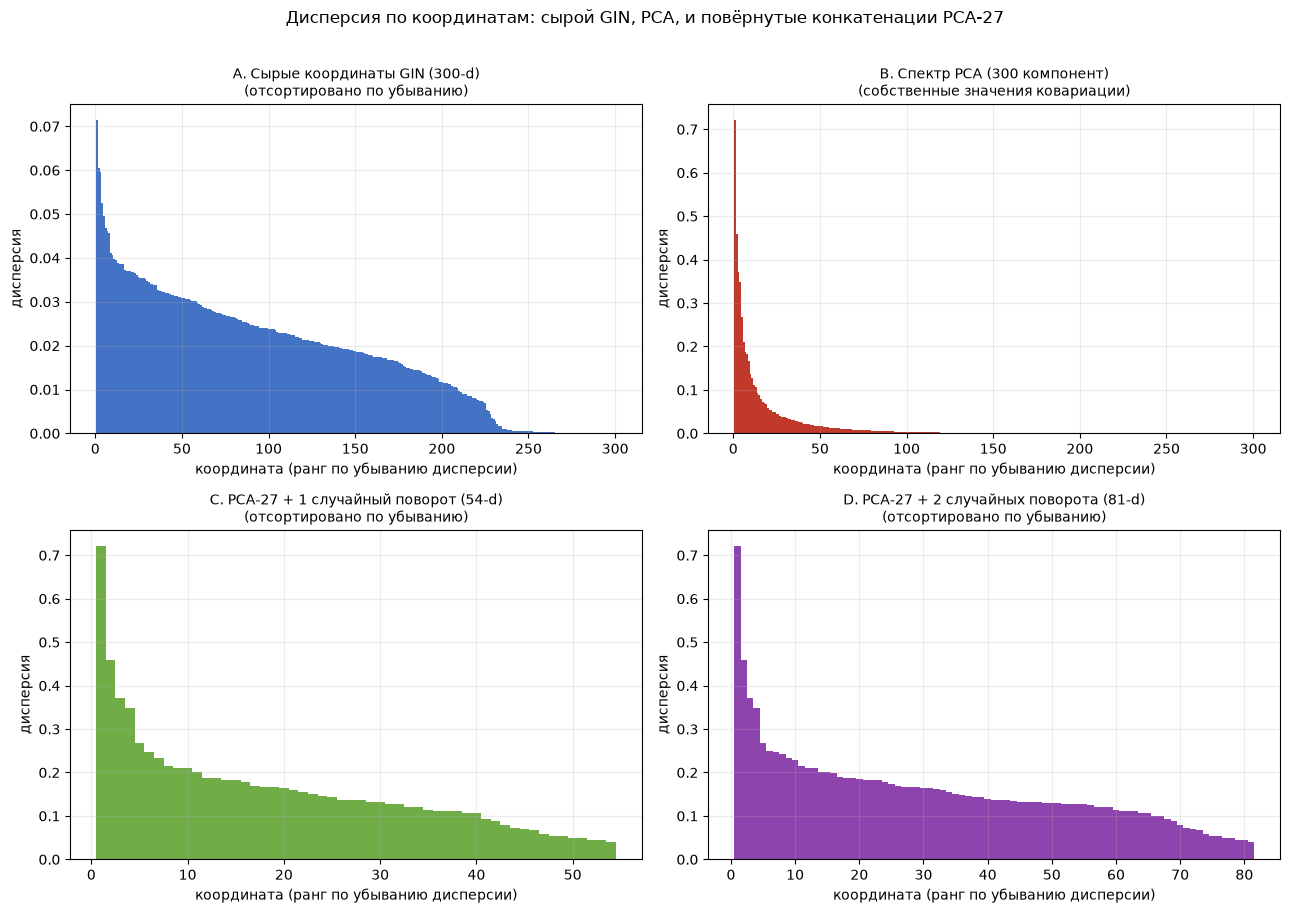

saved -> gin_variance_all_variants.png


In [43]:
# --- дисперсия координат: GIN, PCA (300), PCA27+повороты (54d, 81d) ---------
X_gin = np.stack([GIN[m] for m in GIN.keys()]).astype(np.float64)   # [488, 300]
mol_keys = list(GIN.keys())

# A: сырые координаты GIN
raw_var_sorted = np.sort(X_gin.var(axis=0, ddof=1))[::-1]

# B: спектр PCA (300 компонент)
Xc = X_gin - X_gin.mean(0, keepdims=True)
_, S, _ = np.linalg.svd(Xc, full_matrices=False)
pca_eigvals = (S ** 2) / (len(X_gin) - 1)

# C, D: PCA-27 + повороты — диагностика на ВСЕХ молекулах (PCA fit на полном
# датасете; никакой утечки, т.к. это не участвует в обучении моделей выше)
Z27_full = pca_transform(GIN, mol_keys, 27)
Z54_full = augment_concat(Z27_full, 2, rotate=True, seed=123)
Z81_full = augment_concat(Z27_full, 3, rotate=True, seed=123)

def coord_var_sorted(emb_dict):
    X = np.stack([emb_dict[m] for m in mol_keys]).astype(np.float64)
    return np.sort(X.var(axis=0, ddof=1))[::-1]

var54_sorted = coord_var_sorted(Z54_full)
var81_sorted = coord_var_sorted(Z81_full)

print(f'A (GIN raw, 300d):     сумма дисперсий = {raw_var_sorted.sum():.3f}')
print(f'B (PCA spectrum, 300): сумма дисперсий = {pca_eigvals.sum():.3f}  (= A)')
print(f'C (PCA27+1rot, 54d):   сумма дисперсий = {var54_sorted.sum():.3f}  (= 2 x сумма var PCA-27)')
print(f'D (PCA27+2rot, 81d):   сумма дисперсий = {var81_sorted.sum():.3f}  (= 3 x сумма var PCA-27)')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
panels = [
    (axes[0, 0], raw_var_sorted, 'A. Сырые координаты GIN (300-d)\n(отсортировано по убыванию)', '#4472C4'),
    (axes[0, 1], pca_eigvals,    'B. Спектр PCA (300 компонент)\n(собственные значения ковариации)', '#C0392B'),
    (axes[1, 0], var54_sorted,   'C. PCA-27 + 1 случайный поворот (54-d)\n(отсортировано по убыванию)', '#70AD47'),
    (axes[1, 1], var81_sorted,   'D. PCA-27 + 2 случайных поворота (81-d)\n(отсортировано по убыванию)', '#8E44AD'),
]
for ax, vals, title, color in panels:
    ax.bar(np.arange(1, len(vals) + 1), vals, color=color, width=1.0)
    ax.set_xlabel('координата (ранг по убыванию дисперсии)')
    ax.set_ylabel('дисперсия')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25)

fig.suptitle('Дисперсия по координатам: сырой GIN, PCA, и повёрнутые конкатенации PCA-27', y=1.01)
fig.tight_layout()
fname = FIG / 'gin_variance_all_variants.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname.name}')

---
## full_full: свип числа PCA-компонент **молекулы** (ChemBERTa), белок фиксирован

Аналог свипа выше, но на датасете **full_full** (ChemBERTa+ESM, сплиты LORAX).
Молекулу сжимаем PCA до `k_mol` (train-fit), белок держим фиксированным на
`FF_K_PROT_FIXED` PCA-компонентах ESM (как здесь протеин фиксируется PCA-19).
Две кривые — `transductive` / `inductive_molecule`; `raw` = полный ChemBERTa
(384-d). Кэшируется.

In [44]:
# --- full_full: загрузка данных и хелперы -----------------------------------
# full_full = другой датасет: фичи [ChemBERTa mol (384) || ESM-mean prot (1280)]
# со сплитами LORAX (orbind.legacy.lorax). Два режима: transductive / inductive_molecule.
import json
from orbind.legacy import lorax as L

FF_REGIMES = ['transductive', 'inductive_molecule']
FF_FOLDS = [1, 2, 3, 4, 5]                      # 5 фолдов LORAX -> честный CI по данным
FF_SEED  = 42                                   # фикс: cold-mol RNG (inductive) + XGBoost
ESM_FF, CHEM_FF = L.load_embeddings()
print(f'full_full: ESM {next(iter(ESM_FF.values())).shape[0]}-d, '
      f'ChemBERTa {next(iter(CHEM_FF.values())).shape[0]}-d')


def ff_pca_fit_project(X_all, train_idx, k):
    """PCA fit на train-узлах, проекция ВСЕХ узлов в k-мерный базис (без утечки)."""
    if k is None:
        return X_all.astype(np.float32)
    Xtr = X_all[train_idx].astype(np.float64)
    mu = Xtr.mean(0, keepdims=True)
    _, _, Vt = np.linalg.svd(Xtr - mu, full_matrices=False)
    kk = min(k, Vt.shape[0])
    proj = (X_all.astype(np.float64) - mu) @ Vt[:kk].T
    if kk < k:
        proj = np.pad(proj, ((0, 0), (0, k - kk)))
    return proj.astype(np.float32)


def ff_xy(split, Xm, Xp):
    idx = np.concatenate([split['pos'], split['neg']], axis=0)
    y = np.concatenate([np.ones(len(split['pos'])), np.zeros(len(split['neg']))])
    X = np.concatenate([Xm[idx[:, 0]], Xp[idx[:, 1]]], axis=1)
    return X.astype(np.float32), y.astype(np.float32)


def ff_train_node_idx(splits, col):
    tr = np.concatenate([splits['train']['pos'], splits['train']['neg']], axis=0)
    return np.unique(tr[:, col])

FF_CFILE = CACHE / 'pca_rotation_ff_molecule.json'
_ff_cache = json.loads(FF_CFILE.read_text()) if FF_CFILE.exists() else {}
def _ff_save(): FF_CFILE.write_text(json.dumps(_ff_cache, indent=1))


# --- сетка k_mol (белок фикс. PCA), прогон по (фолд, режим) -----------------
# CI = разброс по 5 фолдам LORAX: fold реально меняет train/test в обоих
# режимах (в т.ч. transductive) -> честный доверительный интервал.
FF_K_GRID_MOL   = [4, 8, 16, 32, 64, 128, 256]
FF_K_PROT_FIXED = 32                                  # белок сжат до 32 PCA (≈ без потерь)
import time

ff_rows = []
for fold in FF_FOLDS:
    for regime in FF_REGIMES:
        Xm, Xp, splits = L.build(regime, fold, ESM_FF, CHEM_FF, seed=FF_SEED)
        Xm, Xp = Xm.numpy(), Xp.numpy()
        tprot = ff_train_node_idx(splits, col=1)
        tmol  = ff_train_node_idx(splits, col=0)
        Xp_fix = ff_pca_fit_project(Xp, tprot, FF_K_PROT_FIXED)     # белок фикс.
        for k in FF_K_GRID_MOL + ['raw']:
            key = f'ff|mol|{regime}|kp{FF_K_PROT_FIXED}|k{k}|fold{fold}|s{FF_SEED}'
            if key in _ff_cache:
                ff_rows.append(_ff_cache[key]); continue
            t0 = time.time()
            Xmk = ff_pca_fit_project(Xm, tmol, None if k == 'raw' else k)
            Xtr, ytr = ff_xy(splits['train'], Xmk, Xp_fix)
            Xte, yte = ff_xy(splits['test'],  Xmk, Xp_fix)
            m = D.metrics(yte, train_boost(Xtr, ytr, Xte, seed=FF_SEED))
            rec = {'regime': regime, 'k': k, 'k_prot': FF_K_PROT_FIXED, 'fold': fold,
                   'train': int(len(ytr)), 'test': int(len(yte)),
                   **{kk: round(float(v), 4) for kk, v in m.items()}}
            _ff_cache[key] = rec; _ff_save(); ff_rows.append(rec)
            print(f"  fold{fold} [{regime:<18} k_mol={str(k):>4}] AUROC={rec['AUROC']:.4f} "
                  f"AUPRC={rec['AUPRC']:.4f} ({time.time()-t0:.1f}s)")
    print(f'  fold {fold} готов')

FF_RES = pd.DataFrame(ff_rows)
print(f'\nfull_full (свип молекулы, белок PCA-{FF_K_PROT_FIXED}): '
      f'{len(FF_RES)} строк ({len(FF_FOLDS)} фолдов на конфигурацию)')

full_full: ESM 1280-d, ChemBERTa 384-d
  nodes: 596 molecules, 1237 proteins
  train: 2333 pos / 38493 neg (pos frac 0.057)
  val  : 219 pos / 3953 neg (pos frac 0.052)
  test : 348 pos / 1217 neg (pos frac 0.222)
  nodes: 596 molecules, 1237 proteins | cold mols: 59 test / 29 val of 296 testable
  train: 2035 pos / 32596 neg (pos frac 0.059)
  val  : 94 pos / 206 neg (pos frac 0.313)
  test : 242 pos / 845 neg (pos frac 0.223)
  fold 1 готов
  nodes: 596 molecules, 1237 proteins
  train: 2297 pos / 38529 neg (pos frac 0.056)
... [92 lines omitted] ...
  fold5 [inductive_molecule k_mol=  32] AUROC=0.7567 AUPRC=0.6002 (8.6s)
  fold5 [inductive_molecule k_mol=  64] AUROC=0.7461 AUPRC=0.6007 (10.0s)
  fold5 [inductive_molecule k_mol= 128] AUROC=0.6944 AUPRC=0.5571 (15.9s)
  fold5 [inductive_molecule k_mol= 256] AUROC=0.6778 AUPRC=0.5315 (30.5s)
  fold5 [inductive_molecule k_mol= raw] AUROC=0.7571 AUPRC=0.6252 (43.7s)
  fold 5 готов

full_full (свип молекулы, белок PCA-32): 80 строк (5 фол

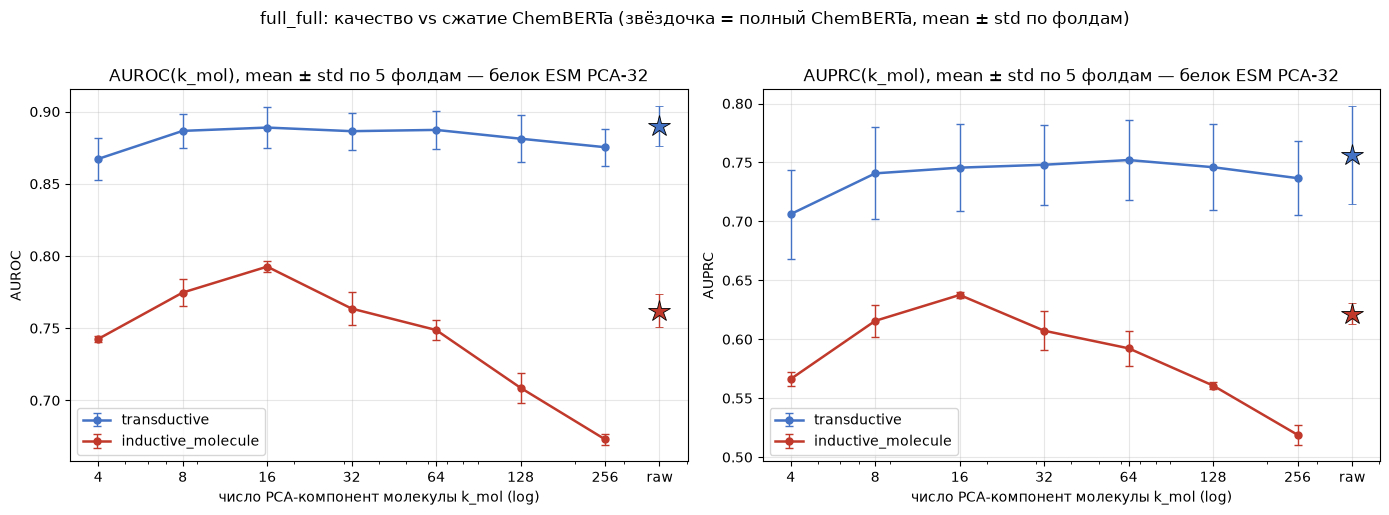

AUROC(k_mol) mean по режимам:


regime,inductive_molecule,transductive
k,,
4,0.7425,0.8673
8,0.7747,0.8867
16,0.7926,0.8890
32,0.7636,0.8865
64,0.7487,0.8873
128,0.7087,0.8812
256,0.6730,0.8754
raw,0.7620,0.8899


In [45]:
# --- график AUROC/AUPRC(k_mol) по режимам, mean ± std по 5 фолдам -----------
RAW_X = 400
col = {'transductive': '#4472C4', 'inductive_molecule': '#C0392B'}

def ff_agg_ms(df, metric):
    g = df.groupby(['k', 'regime'])[metric]
    return g.mean().rename('mean').to_frame().join(g.std().rename('std')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax in zip(['AUROC', 'AUPRC'], axes):
    A = ff_agg_ms(FF_RES, metric)
    for regime in FF_REGIMES:
        sub = A[A['regime'] == regime]
        num = sub[sub['k'] != 'raw'].assign(k=lambda d: d['k'].astype(int)).sort_values('k')
        ax.errorbar(num['k'], num['mean'], yerr=num['std'], marker='o', color=col[regime],
                    label=regime, lw=1.8, ms=5, capsize=3, elinewidth=1)
        raw = sub[sub['k'] == 'raw']
        if not raw.empty:
            ax.errorbar([RAW_X], raw['mean'], yerr=raw['std'], color=col[regime], marker='*',
                        ms=16, mec='k', mew=0.6, capsize=3, elinewidth=1, ls='none', zorder=5)
    ax.set_xscale('log')
    ax.set_xticks(FF_K_GRID_MOL + [RAW_X]); ax.set_xticklabels([str(k) for k in FF_K_GRID_MOL] + ['raw'])
    ax.set_xlabel('число PCA-компонент молекулы k_mol (log)'); ax.set_ylabel(metric)
    ax.set_title(f'{metric}(k_mol), mean ± std по {len(FF_FOLDS)} фолдам — белок ESM PCA-{FF_K_PROT_FIXED}')
    ax.legend(); ax.grid(alpha=.3)
fig.suptitle('full_full: качество vs сжатие ChemBERTa (звёздочка = полный ChemBERTa, mean ± std по фолдам)', y=1.02)
fig.tight_layout(); fig.savefig(FIG / 'ff_pca_k_mol.png', dpi=140, bbox_inches='tight'); plt.show()

order = FF_K_GRID_MOL + ['raw']
tbl = (ff_agg_ms(FF_RES, 'AUROC').assign(k=lambda d: d['k'].astype(str))
       .pivot_table(index='k', columns='regime', values='mean', aggfunc='first')
       .reindex([str(k) for k in order]))
print('AUROC(k_mol) mean по режимам:'); display(tbl.round(4))